In [397]:
import numpy as np
import pandas as pd
import re

In [398]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [399]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [400]:
df.duplicated().sum()

np.int64(122)

In [401]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,independent,sector 12,3.5,133079.0,263.0,Plot area 263(24.43 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 4400 sq.ft. (408.77 sq.m.),8.0,8.0,3+,"pooja room,study room,servant room",3.0,South-East,1 to 5 Year Old,"['Hanuman Mandir', 'Dental Health Centre', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'M Goel Hospital', 'Lall Eye Care Centre', 'Dentecare - Multispeciality Dental Clinic', 'Lalit Dental Care', 'Kharbanda Maternity and Nursing Home', 'Ahooja Eye and Dental Institute Hospital', 'Gupta Hospital Gurgaon', 'Jackson Hospital', 'Kidney Clinic', 'Dr. Sandeep Chauhan', 'Centre For Sight Gurgaon New Railway Road', 'Dr. Sarvejeet Singh', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Dr. Ajay S. Gupta Clinic', 'Mamta Hospital Gurgaon', 'Bhatnagar Maternity and Nursing Home', 'Lotus Hospital Gurgaon', 'Triveni Hospital Gurgaon', 'Bindal Clinic', 'M.S Hospital', 'Sparsh Hospital Gurgaon', 'Dr. Agya Ram Sharma Clinic', 'My Care Clinic', 'Ravi Clinic and Health Care Centre', 'D.R. Rajnis Gupta Clinic', 'GH Gurgaon', 'Saraswati Hospital Gurgaon', 'Nidhi Clinic', 'Aarvy Hospital', 'Aryan Hospital', 'Geeta Nursing Home Gurgaon', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Dr. Tomar Clinic', 'Dr. Babita Sharma', 'Indian Oil', 'Rang Parivartan', 'Punjab national bank', 'State bank of india sbi', 'State bank of india', 'Dronacharya Government College', 'govt sec school', 'District library gurgaon']","['1 Water Purifier', '14 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '40 Light', '4 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '8 Wardrobe', '1 Sofa', 'No Bed', 'No Microwave', 'No Fridge', 'No Stove', 'No TV', 'No Washing Machine']","['Private Garden / Terrace', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'Recently Renovated', 'Visitor Parking', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']"


1. areaWithType

In [402]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1296,1.30,894.0,Super Built up area 1400(130.06 sq.m.)Carpet area: 894 sq.ft. (83.06 sq.m.)
16,1.75,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.)
1819,1.27,1299.0,Carpet area: 1304 (121.15 sq.m.)
730,0.82,832.0,Carpet area: 77.31
463,2.20,2100.0,Super Built up area 2100(195.1 sq.m.)


In [403]:
 # This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [404]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [405]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [406]:
df['areaWithType'].isna().sum()

np.int64(1)

In [407]:
df['areaWithType'] = df['areaWithType'].fillna('')

In [408]:
df['areaWithType'].isna().sum()

np.int64(0)

In [409]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [410]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2004,5.70,flat,1382.0,Built Up area: 1382 (128.39 sq.m.),NaN,1382.0,NaN
1849,1.18,flat,1565.0,Super Built up area 1565(145.39 sq.m.),1565.0,NaN,NaN
435,2.15,flat,1433.0,Built Up area: 1433 (133.13 sq.m.),NaN,1433.0,NaN
1718,0.69,house,758.0,Built Up area: 758 (70.42 sq.m.)Carpet area: 500 sq.ft. (46.45 sq.m.),NaN,758.0,500.0
967,0.82,flat,1180.0,Super Built up area 1180(109.63 sq.m.),1180.0,NaN,NaN


In [411]:
df.duplicated().sum()

np.int64(122)

In [412]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [413]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,3.50,house,263.0,Plot area 263(24.43 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 4400 sq.ft. (408.77 sq.m.),NaN,4800.0,4400.0
3,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,NaN,NaN
8,6.50,house,1836.0,Plot area 215(179.77 sq.m.)Built Up area: 215 sq.yards (179.77 sq.m.),NaN,215.0,NaN
11,5.60,house,4000.0,Plot area 4000(371.61 sq.m.),NaN,NaN,NaN
20,0.55,house,820.0,Plot area 820(76.18 sq.m.)Built Up area: 810 sq.ft. (75.25 sq.m.)Carpet area: 715 sq.ft. (66.43 sq.m.),NaN,810.0,715.0


In [414]:
df.isnull().sum()

,0
property_type,1
society,2
sector,0
price,19
price_per_sqft,19
area,19
areaWithType,0
bedRoom,1
bathroom,1
balcony,1


In [415]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [416]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,NaN,NaN
11,5.6,house,4000.0,Plot area 4000(371.61 sq.m.),NaN,NaN,NaN
25,18.9,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
26,5.5,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
41,14.0,house,3510.0,Plot area 390(326.09 sq.m.),NaN,NaN,NaN


In [417]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [418]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [419]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [420]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3193,0.96,house,960.0,Plot area 945(87.79 sq.m.),NaN,945.0,NaN
2573,3.50,house,2367.0,Plot area 263(219.9 sq.m.),NaN,263.0,NaN
3745,NaN,house,NaN,Plot area 270(225.75 sq.m.),NaN,270.0,NaN
724,2.40,house,900.0,Plot area 100(83.61 sq.m.),NaN,100.0,NaN
3654,6.20,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.0,NaN


In [421]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [422]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [423]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,350.00,NaN
11,5.60,house,4000.0,Plot area 4000(371.61 sq.m.),NaN,4000.00,NaN
25,18.90,house,4518.0,Plot area 502(419.74 sq.m.),NaN,4518.00,NaN
26,5.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
41,14.00,house,3510.0,Plot area 390(326.09 sq.m.),NaN,3510.00,NaN
42,0.61,house,61.0,Plot area 61(5.67 sq.m.),NaN,61.00,NaN
55,8.10,house,2295.0,Plot area 255(213.21 sq.m.),NaN,2295.00,NaN
63,4.31,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
67,6.75,house,232.0,Plot area 232(21.55 sq.m.),NaN,232.00,NaN
68,2.75,house,1080.0,Plot area 120(100.34 sq.m.),NaN,1080.00,NaN


In [424]:
# update the original dataframe
df.update(all_nan_df)

In [425]:
df.isnull().sum()

,0
property_type,1
society,2
sector,0
price,19
price_per_sqft,19
area,19
areaWithType,0
bedRoom,1
bathroom,1
balcony,1


In [426]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,independent,sector 12,3.50,133079.0,263.0,Plot area 263(24.43 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 4400 sq.ft. (408.77 sq.m.),8.0,8.0,3+,"pooja room,study room,servant room",3.0,South-East,1 to 5 Year Old,"['Hanuman Mandir', 'Dental Health Centre', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'M Goel Hospital', 'Lall Eye Care Centre', 'Dentecare - Multispeciality Dental Clinic', 'Lalit Dental Care', 'Kharbanda Maternity and Nursing Home', 'Ahooja Eye and Dental Institute Hospital', 'Gupta Hospital Gurgaon', 'Jackson Hospital', 'Kidney Clinic', 'Dr. Sandeep Chauhan', 'Centre For Sight Gurgaon New Railway Road', 'Dr. Sarvejeet Singh', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Dr. Ajay S. Gupta Clinic', 'Mamta Hospital Gurgaon', 'Bhatnagar Maternity and Nursing Home', 'Lotus Hospital Gurgaon', 'Triveni Hospital Gurgaon', 'Bindal Clinic', 'M.S Hospital', 'Sparsh Hospital Gurgaon', 'Dr. Agya Ram Sharma Clinic', 'My Care Clinic', 'Ravi Clinic and Health Care Centre', 'D.R. Rajnis Gupta Clinic', 'GH Gurgaon', 'Saraswati Hospital Gurgaon', 'Nidhi Clinic', 'Aarvy Hospital', 'Aryan Hospital', 'Geeta Nursing Home Gurgaon', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Dr. Tomar Clinic', 'Dr. Babita Sharma', 'Indian Oil', 'Rang Parivartan', 'Punjab national bank', 'State bank of india sbi', 'State bank of india', 'Dronacharya Government College', 'govt sec school', 'District library gurgaon']","['1 Water Purifier', '14 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '40 Light', '4 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '8 Wardrobe', '1 Sofa', 'No Bed', 'No Microwave', 'No Fridge', 'No Stove', 'No TV', 'No Washing Machine']","['Private Garden / Terrace', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'Recently Renovated', 'Visitor Parking', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,4800.0,4400.0
1,flat,Paras Dews,sector 106,1.14,6000.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up area: 1305 sq.ft. (121.24 sq.m.)Carpet area: 1173 sq.ft. (108.98 sq.m.),3.0,4.0,3,"study room,servant room",8.0,South,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1900.0,1305.0,1173.0
2,flat,Tulip Monsella,sector 53,8.25,28000.0,2946.0,Super Built up area 2940(273.13 sq.m.),3.0,4.0,3,servant room,8.0,NaN,Nov 2025,"['Sector 53-54 Metro Station', 'Central Plaza Mall', 'The Big Tree Cafe', 'IILM University, Gurugram', 'The Banyan Tree World School', 'Sanar International Hospital', 'DLF Golf and Country Club', 'Mavens Inn', 'DoubleTree by Hilton Hotel']","['1 Water Purifier', '1 Fridge', '1 Washing Machine', '1 Stove', '1 Microwave', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Sofa', 'No TV', 'No Wardrobe']","['Feng Shui / Vaastu Compliant', 'Lift(s)', 'Swimming Pool', 'Internet/wi-fi connectivity', 'S

2.additionalRoom

In [427]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
not available,1587
servant room,705
study room,250
others,225
pooja room,165
store room,99
"study room,servant room",99
"pooja room,servant room",82
"pooja room,study room,servant room,store room",72


In [428]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col, na=False).astype(int)

In [429]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
3469,store room,0,0,1,0,0
27,pooja room,0,0,0,1,0
2920,not available,0,0,0,0,0
2340,"servant room,others",0,1,0,0,1
313,study room,1,0,0,0,0


In [430]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,independent,sector 12,3.50,133079.0,263.0,Plot area 263(24.43 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 4400 sq.ft. (408.77 sq.m.),8.0,8.0,3+,"pooja room,study room,servant room",3.0,South-East,1 to 5 Year Old,"['Hanuman Mandir', 'Dental Health Centre', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'M Goel Hospital', 'Lall Eye Care Centre', 'Dentecare - Multispeciality Dental Clinic', 'Lalit Dental Care', 'Kharbanda Maternity and Nursing Home', 'Ahooja Eye and Dental Institute Hospital', 'Gupta Hospital Gurgaon', 'Jackson Hospital', 'Kidney Clinic', 'Dr. Sandeep Chauhan', 'Centre For Sight Gurgaon New Railway Road', 'Dr. Sarvejeet Singh', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Dr. Ajay S. Gupta Clinic', 'Mamta Hospital Gurgaon', 'Bhatnagar Maternity and Nursing Home', 'Lotus Hospital Gurgaon', 'Triveni Hospital Gurgaon', 'Bindal Clinic', 'M.S Hospital', 'Sparsh Hospital Gurgaon', 'Dr. Agya Ram Sharma Clinic', 'My Care Clinic', 'Ravi Clinic and Health Care Centre', 'D.R. Rajnis Gupta Clinic', 'GH Gurgaon', 'Saraswati Hospital Gurgaon', 'Nidhi Clinic', 'Aarvy Hospital', 'Aryan Hospital', 'Geeta Nursing Home Gurgaon', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Dr. Tomar Clinic', 'Dr. Babita Sharma', 'Indian Oil', 'Rang Parivartan', 'Punjab national bank', 'State bank of india sbi', 'State bank of india', 'Dronacharya Government College', 'govt sec school', 'District library gurgaon']","['1 Water Purifier', '14 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '40 Light', '4 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '8 Wardrobe', '1 Sofa', 'No Bed', 'No Microwave', 'No Fridge', 'No Stove', 'No TV', 'No Washing Machine']","['Private Garden / Terrace', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'Recently Renovated', 'Visitor Parking', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,4800.0,4400.0,1,1,0,1,0
1,flat,Paras Dews,sector 106,1.14,6000.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up area: 1305 sq.ft. (121.24 sq.m.)Carpet area: 1173 sq.ft. (108.98 sq.m.),3.0,4.0,3,"study room,servant room",8.0,South,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1900.0,1305.0,1173.0,1,1,0,0,0
2,flat,Tulip Monsella,sector 53,8.25,28000.0,2946.0,Super Built up area 2940(273.13 sq.m.),3.0,4.0,3,servant room,8.0,NaN,Nov 2025,"['Sector 53-54 Metro Station', 'Central Plaza Mall', 'The Big Tree Cafe', 'IILM University, Gurugram', 'The Banyan Tree World School', 'Sanar International Hospital', 'DLF Golf and Country Club', 'Mavens Inn', 'DoubleTree by Hilton Hotel']","['1 Water Purifier', '1 Fridge', '1 Washing Machine', '1 Stove', '1 Microwave', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Sofa', 'No TV', 'No Wardrobe']","['Feng Shui / Vaastu 

3.agePossession

In [431]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,1676
5 to 10 Year Old,575
0 to 1 Year Old,530
undefined,332
10+ Year Old,310
Under Construction,90
Within 6 months,70
Within 3 months,26
Dec 2023,22


In [432]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [433]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [434]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1676
New Property,626
Moderately Old,575
Undefined,334
Old Property,310
Under Construction,283


In [435]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,independent,sector 12,3.50,133079.0,263.0,Plot area 263(24.43 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 4400 sq.ft. (408.77 sq.m.),8.0,8.0,3+,"pooja room,study room,servant room",3.0,South-East,Relatively New,"['Hanuman Mandir', 'Dental Health Centre', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'M Goel Hospital', 'Lall Eye Care Centre', 'Dentecare - Multispeciality Dental Clinic', 'Lalit Dental Care', 'Kharbanda Maternity and Nursing Home', 'Ahooja Eye and Dental Institute Hospital', 'Gupta Hospital Gurgaon', 'Jackson Hospital', 'Kidney Clinic', 'Dr. Sandeep Chauhan', 'Centre For Sight Gurgaon New Railway Road', 'Dr. Sarvejeet Singh', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Dr. Ajay S. Gupta Clinic', 'Mamta Hospital Gurgaon', 'Bhatnagar Maternity and Nursing Home', 'Lotus Hospital Gurgaon', 'Triveni Hospital Gurgaon', 'Bindal Clinic', 'M.S Hospital', 'Sparsh Hospital Gurgaon', 'Dr. Agya Ram Sharma Clinic', 'My Care Clinic', 'Ravi Clinic and Health Care Centre', 'D.R. Rajnis Gupta Clinic', 'GH Gurgaon', 'Saraswati Hospital Gurgaon', 'Nidhi Clinic', 'Aarvy Hospital', 'Aryan Hospital', 'Geeta Nursing Home Gurgaon', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Dr. Tomar Clinic', 'Dr. Babita Sharma', 'Indian Oil', 'Rang Parivartan', 'Punjab national bank', 'State bank of india sbi', 'State bank of india', 'Dronacharya Government College', 'govt sec school', 'District library gurgaon']","['1 Water Purifier', '14 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '40 Light', '4 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '8 Wardrobe', '1 Sofa', 'No Bed', 'No Microwave', 'No Fridge', 'No Stove', 'No TV', 'No Washing Machine']","['Private Garden / Terrace', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'Recently Renovated', 'Visitor Parking', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,4800.0,4400.0,1,1,0,1,0
1,flat,Paras Dews,sector 106,1.14,6000.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up area: 1305 sq.ft. (121.24 sq.m.)Carpet area: 1173 sq.ft. (108.98 sq.m.),3.0,4.0,3,"study room,servant room",8.0,South,Relatively New,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1900.0,1305.0,1173.0,1,1,0,0,0
2,flat,Tulip Monsella,sector 53,8.25,28000.0,2946.0,Super Built up area 2940(273.13 sq.m.),3.0,4.0,3,servant room,8.0,NaN,Under Construction,"['Sector 53-54 Metro Station', 'Central Plaza Mall', 'The Big Tree Cafe', 'IILM University, Gurugram', 'The Banyan Tree World School', 'Sanar International Hospital', 'DLF Golf and Country Club', 'Mavens Inn', 'DoubleTree by Hilton Hotel']","['1 Water Purifier', '1 Fridge', '1 Washing Machine', '1 Stove', '1 Microwave', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Sofa', 'No TV', 'No Wardrobe']","['Feng Shui /

4.furnishDetails

In [436]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
662,"['6 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Visitor Parking']"
1535,"['1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
3189,NaN,"['Lift(s)', 'Maintenance Staff', 'Park']"
567,"['8 Wardrobe', '10 Fan', '1 Exhaust Fan', '10 Geyser', '1 Stove', '30 Light', '1 Modular Kitchen', '4 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Private Garden / Terrace', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']"
1628,"['1 Water Purifier', '5 Fan', '1 Exhaust Fan', '10 Light', '2 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine']","['Security / Fire Alarm', 'Private Garden / Terrace', 'Swimming Pool', 'Visitor Parking', 'Security Personnel', 'Club house / Community Center', 'Waste Disposal']"


In [437]:
 # Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8258/542588310.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [438]:
furnishings_df.shape

(3804, 19)

In [439]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipykernel_8258/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [440]:
furnishings_df.sample(5)

,Bed,Stove,Washing Machine,Sofa,Wardrobe,Water Purifier,Fridge,AC,Exhaust Fan,Fan,Dining Table,Geyser,Chimney,Modular Kitchen,Microwave,Curtains,TV,Light
3539,2,1,0,0,3,0,1,0,0,0,1,1,0,1,0,0,0,8
3103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2865,0,0,0,0,0,0,0,5,1,5,0,0,1,1,0,0,0,5
2443,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [441]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [442]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [443]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

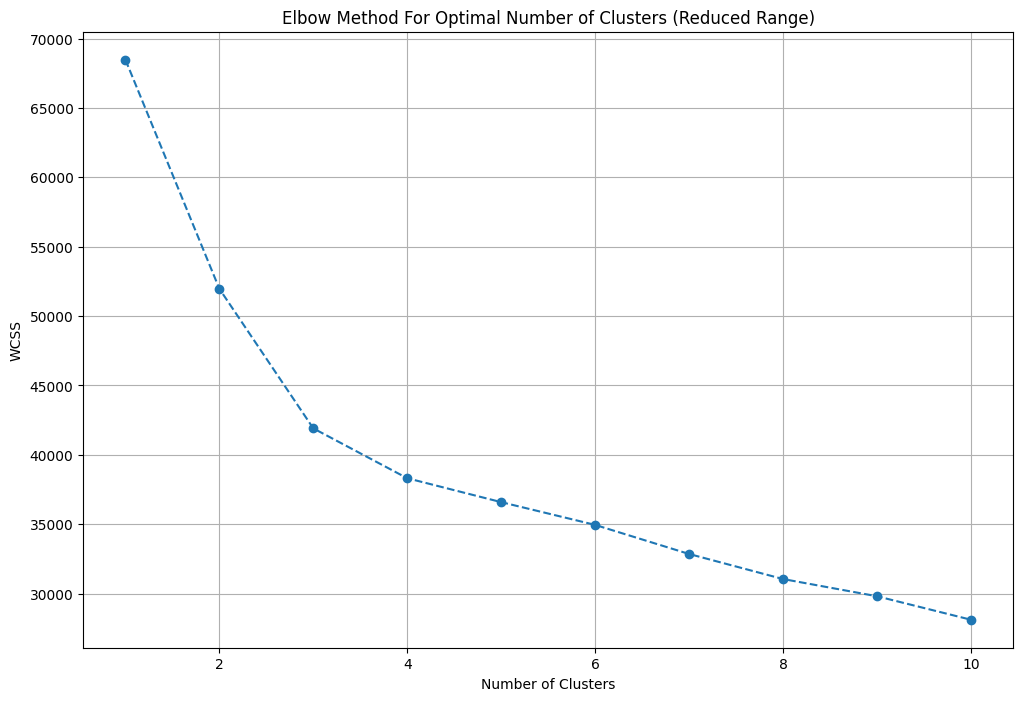

In [444]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [445]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [446]:
df = df.iloc[:,:-18]

In [447]:
df['furnishing_type'] = cluster_assignments

In [448]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
3481,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '5 Geyser', '20 Light', '7 AC', '1 Chimney', '6 Curtains', '1 Modular Kitchen', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
1352,"['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '15 Light', '4 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
2710,"['1 Stove', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
2530,NaN,0
563,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0


5.features

In [449]:
df[['society','features']].sample(5)

,society,features
2956,independent,NaN
1984,Spaze Privvy The Address3.9 ★,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'Water purifier', 'Maintenance Staff', 'False Ceiling Lighting', 'Recently Renovated', 'Visitor Parking', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors']"
2363,Shree Vardhman Victoria3.8 ★,"['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3195,Proxima Tower,"['Lift(s)', 'Centrally Air Conditioned', 'Swimming Pool', 'Security Personnel', 'Maintenance Staff', 'Park', 'Visitor Parking', 'Piped-gas', 'Fitness Centre / GYM']"
371,independent,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Water Storage', 'Park']"


In [450]:
df['features'].isnull().sum()

np.int64(636)

In [451]:
import pandas as pd
app_df = pd.read_csv('/content/real_estate_data - real_estate_data.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [452]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()


In [453]:
temp_df = df[df['features'].isnull()]


In [454]:
temp_df.shape


(636, 26)

In [455]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']


In [456]:
df.loc[temp_df.index,'features'] = x.values


In [457]:
df['features'].isnull().sum()


np.int64(619)

In [458]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast


In [459]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [460]:
features_binary_df.sample(5)

,24/7 Power Backup,24x7 Security,ATM,Aerobics Centre,Airy Rooms,Amphitheatre,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Creche/Day care,Cricket Pitch,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Landscape Garden,Laundry,Lawn Tennis Court,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Natural Light,No open drainage around,Park,Pergola,Piped Gas,Piped-gas,Power Back-up,Private Garden / Terrace,Property Staff,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Terrace Garden,Video Door Security,Visitor Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2929,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3244,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,1,1,0,0,0,0,1,1,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0
2774,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1156,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
439,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [461]:
features_binary_df.shape


(3804, 96)

In [462]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

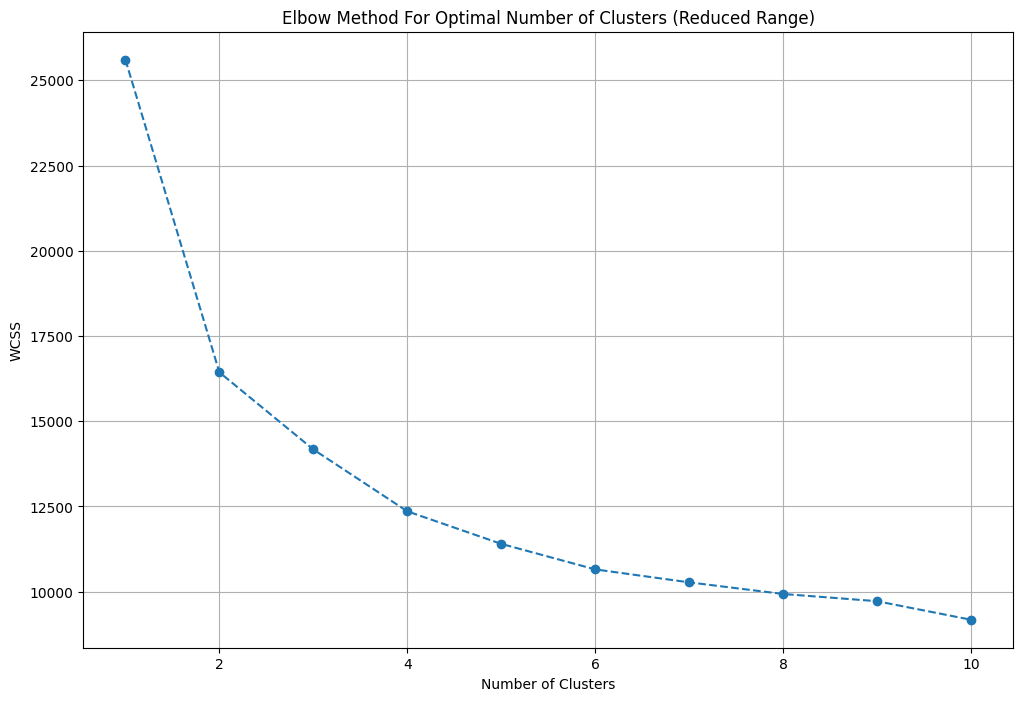

In [463]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [464]:
print(features_binary_df.columns.tolist())

['24/7 Power Backup', '24x7 Security', 'ATM', 'Aerobics Centre', 'Airy Rooms', 'Amphitheatre', 'Bank Attached Property', 'Banquet Hall', 'Bar/Chill-Out Lounge', 'Barbecue', 'Bowling Alley', 'Bus Shelter', 'Business Lounge', 'CCTV Camera Security', 'Cafeteria', 'Card Room', 'Centrally Air Conditioned', 'Changing Area', "Children's Play Area", 'Cigar Lounge', 'Clinic', 'Club House', 'Club house / Community Center', 'Community Hall', 'Creche/Day care', 'Cricket Pitch', 'Earthquake Resistant', 'Entrance Lobby', 'False Ceiling Lighting', 'Feng Shui / Vaastu Compliant', 'Fire Fighting Systems', 'Fitness Centre / GYM', 'Flower Garden', 'Fountain', 'Gated Community', 'Gazebo', 'Golf Course', 'Grocery Shop', 'Gymnasium', 'High Ceiling Height', 'Intercom Facility', 'Internal Street Lights', 'Internet/wi-fi connectivity', 'Jacuzzi', 'Landscape Garden', 'Laundry', 'Lawn Tennis Court', 'Lift(s)', 'Lounge', 'Low Density Society', 'Maintenance Staff', 'Manicured Garden', 'Medical Centre', 'Milk Booth

In [465]:
weights = {
    '24/7 Power Backup': 6,
    '24x7 Security': 5,
    'ATM': 2,
    'Aerobics Centre': 6,
    'Airy Rooms': 7,
    'Amphitheatre': 7,
    'Bank Attached Property': 2,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Bowling Alley': 10,
    'Bus Shelter': 1,
    'Business Lounge': 8,
    'CCTV Camera Security': 4,
    'Cafeteria': 5,
    'Card Room': 7,
    'Centrally Air Conditioned': 10,
    'Changing Area': 3,
    "Children's Play Area": 4,
    'Cigar Lounge': 10,
    'Clinic': 3,
    'Club House': 8,
    'Club house / Community Center': 7,
    'Community Hall': 4,
    'Creche/Day care': 4,
    'Cricket Pitch': 7,
    'Earthquake Resistant': 4,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 3,
    'Fire Fighting Systems': 4,
    'Fitness Centre / GYM': 7,
    'Flower Garden': 5,
    'Fountain': 6,
    'Gated Community': 5,
    'Gazebo': 6,
    'Golf Course': 10,
    'Grocery Shop': 3,
    'Gymnasium': 7,
    'High Ceiling Height': 9,
    'Intercom Facility': 5,
    'Internal Street Lights': 4,
    'Internet/wi-fi connectivity': 5,
    'Jacuzzi': 10,
    'Landscape Garden': 7,
    'Laundry': 4,
    'Lawn Tennis Court': 8,
    'Lift(s)': 5,
    'Lounge': 7,
    'Low Density Society': 9,
    'Maintenance Staff': 5,
    'Manicured Garden': 8,
    'Medical Centre': 4,
    'Milk Booth': 1,
    'Mini Theatre': 9,
    'Natural Light': 8,
    'No open drainage around': 3,
    'Park': 4,
    'Pergola': 6,
    'Piped Gas': 5,
    'Piped-gas': 5,
    'Power Back-up': 6,
    'Private Garden / Terrace': 9,
    'Property Staff': 5,
    'Rain Water Harvesting': 4,
    'Reading Lounge': 6,
    'Recently Renovated': 5,
    'Reflexology Park': 7,
    'Restaurant': 7,
    'Salon': 6,
    'Sauna': 9,
    'School': 4,
    'Security / Fire Alarm': 5,
    'Security Personnel': 5,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 4,
    'Shopping Centre': 5,
    'Skating Rink': 7,
    'Solar Lighting': 5,
    'Spa': 10,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Terrace Garden': 8,
    'Video Door Security': 6,
    'Visitor Parking': 4,
    'Volley Ball Court': 6,
    'Waiting Lounge': 5,
    'Waste Disposal': 3,
    'Water Storage': 4,
    'Water purifier': 3,
    'Water softening plant': 5,
    'Wi-Fi Connectivity': 5,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [466]:
df['luxury_score'] = luxury_score


In [467]:
df.head()


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,independent,sector 12,3.50,133079.0,263.0,Plot area 263(24.43 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 4400 sq.ft. (408.77 sq.m.),8.0,8.0,3+,"pooja room,study room,servant room",3.0,South-East,Relatively New,"['Hanuman Mandir', 'Dental Health Centre', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'M Goel Hospital', 'Lall Eye Care Centre', 'Dentecare - Multispeciality Dental Clinic', 'Lalit Dental Care', 'Kharbanda Maternity and Nursing Home', 'Ahooja Eye and Dental Institute Hospital', 'Gupta Hospital Gurgaon', 'Jackson Hospital', 'Kidney Clinic', 'Dr. Sandeep Chauhan', 'Centre For Sight Gurgaon New Railway Road', 'Dr. Sarvejeet Singh', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Dr. Ajay S. Gupta Clinic', 'Mamta Hospital Gurgaon', 'Bhatnagar Maternity and Nursing Home', 'Lotus Hospital Gurgaon', 'Triveni Hospital Gurgaon', 'Bindal Clinic', 'M.S Hospital', 'Sparsh Hospital Gurgaon', 'Dr. Agya Ram Sharma Clinic', 'My Care Clinic', 'Ravi Clinic and Health Care Centre', 'D.R. Rajnis Gupta Clinic', 'GH Gurgaon', 'Saraswati Hospital Gurgaon', 'Nidhi Clinic', 'Aarvy Hospital', 'Aryan Hospital', 'Geeta Nursing Home Gurgaon', 'Chiranjiv Hospital', 'Swastik Maternity and Medical Centre', 'Dr. Tomar Clinic', 'Dr. Babita Sharma', 'Indian Oil', 'Rang Parivartan', 'Punjab national bank', 'State bank of india sbi', 'State bank of india', 'Dronacharya Government College', 'govt sec school', 'District library gurgaon']","['1 Water Purifier', '14 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '40 Light', '4 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '8 Wardrobe', '1 Sofa', 'No Bed', 'No Microwave', 'No Fridge', 'No Stove', 'No TV', 'No Washing Machine']","['Private Garden / Terrace', 'High Ceiling Height', 'False Ceiling Lighting', 'Separate entry for servant room', 'Recently Renovated', 'Visitor Parking', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting']",NaN,4800.0,4400.0,1,1,0,1,0,2,"[Private Garden / Terrace, High Ceiling Height, False Ceiling Lighting, Separate entry for servant room, Recently Renovated, Visitor Parking, Natural Light, Internet/wi-fi connectivity, Airy Rooms, Spacious Interiors, Rain Water Harvesting]",74
1,flat,Paras Dews,sector 106,1.14,6000.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up area: 1305 sq.ft. (121.24 sq.m.)Carpet area: 1173 sq.ft. (108.98 sq.m.),3.0,4.0,3,"study room,servant room",8.0,South,Relatively New,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1900.0,1305.0,1173.0,1,1,0,0,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",35
2,flat,Tulip Monsella,sector 53,8.25,28000.0,2946.0,Super Built up area 2940(273.13 sq.m.),3.0,4.0,3,servant room,8.0,NaN,Under Construction,"['Sector 53-54 Metro Station', 'Central Plaza Mall', 'The Big Tree Cafe', '

In [468]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)


In [469]:
df.sample(5)


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3060,flat,ATS Triumph3.9 ★,sector 104,2.00,8733.0,2290.0,Super Built up area 2290(212.75 sq.m.),3.0,4.0,3+,4.0,NaN,Relatively New,2290.0,NaN,NaN,0,1,0,0,0,0,66
2321,house,independent,sector 25,10.85,38150.0,2844.0,Plot area 316(264.22 sq.m.),6.0,6.0,1,3.0,North-East,Relatively New,NaN,2844.0,NaN,0,0,1,0,0,1,130
822,flat,Sare Green Parc 2,sector 92,0.75,4745.0,1581.0,Super Built up area 1454(135.08 sq.m.)Built Up area: 1415 sq.ft. (131.46 sq.m.)Carpet area: 1350 sq.ft. (125.42 sq.m.),3.0,3.0,3,2.0,East,Relatively New,1454.0,1415.0,1350.0,0,0,0,0,1,1,35
2809,house,independent,sector 3,0.80,8155.0,981.0,Plot area 109(91.14 sq.m.),5.0,4.0,1,2.0,NaN,Moderately Old,NaN,981.0,NaN,0,0,0,0,0,0,0
3621,house,international city by sobha phase 2,sector 109,7.00,12963.0,5400.0,Plot area 600(501.68 sq.m.),5.0,6.0,2,2.0,West,Relatively New,NaN,5400.0,NaN,0,1,0,0,0,0,139


In [470]:
df.shape


(3804, 23)

In [471]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)
